<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/Taller_Naive_Bayes_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TALLER: MODELOS NAIVE BAYES

Nombre: Santiago Arroyo



In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


In [16]:
#Tratamiento de las clases del dataset
#Se realiza un intercambio de posiciones de clases

datos = load_breast_cancer()

X = datos.data

# Clase original:
# 0 = malignant
# 1 = benign

# Intercambio de clases:
# 0 = benign
# 1 = malignant
y = 1 - datos.target

nombres_clases = ["benign", "malignant"]



Accuracy Gaussiano NB 0.9210526315789473
Precision Gaussiano NB: 0.8809523809523809
Recall Gaussiano NB: 0.9024390243902439
F1-Score Gaussiano NB: 0.891566265060241
AUC-ROC Gaussiano NB: 0.9839625793518209

Reporte de clasificación - Gaussiano NB:
              precision    recall  f1-score   support

      benign       0.94      0.93      0.94        73
   malignant       0.88      0.90      0.89        41

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.91       114
weighted avg       0.92      0.92      0.92       114



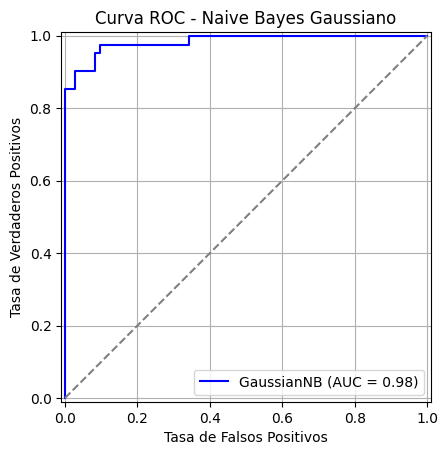

Matriz de confusión - Gaussiano NB:
[[68  5]
 [ 4 37]]


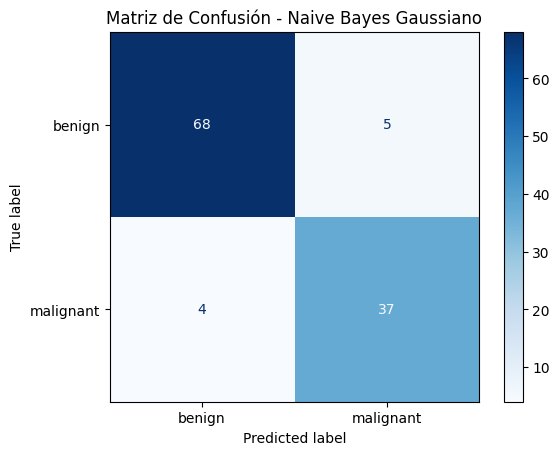


Interpretación Gaussiano NB:
El Accuracy indica el porcentaje total de predicciones correctas.
La Precision indica qué tan confiables son las predicciones positivas.
El Recall indica qué tan bien el modelo detecta los casos positivos reales.
El F1-Score resume Precision y Recall en una sola métrica.
El AUC-ROC indica qué tan bien el modelo separa las clases benigno y maligno.


In [ ]:
#Naive Bayes Gaussiano



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

modelo = GaussianNB()

modelo.fit(X_train,y_train)

y_pred = modelo.predict(X_test)

# Probabilidades necesarias para calcular AUC-ROC
y_prob = modelo.predict_proba(X_test)[:, 1]


print("Accuracy Gaussiano NB",
    accuracy_score(
        y_test,
        y_pred
    )
)
#TODO: REALIZAR CONTRASTE CON OTRAS METRICAS DE EVALUACIÓN E INTERPRETAR RESULTADOS.
# Y VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN

print("Precision Gaussiano NB:",
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print("Recall Gaussiano NB:",
    recall_score(
        y_test,
        y_pred
    )
)

print("F1-Score Gaussiano NB:",
    f1_score(
        y_test,
        y_pred
    )
)

print("AUC-ROC Gaussiano NB:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

print("\nReporte de clasificación - Gaussiano NB:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=nombres_clases,
        zero_division=0
    )
)



#Curva ROC-AUC
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="GaussianNB",
    color="blue"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Naive Bayes Gaussiano")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.grid()
plt.show()

#Matriz de Confusión

matriz_gaussiano = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de confusión - Gaussiano NB:")
print(matriz_gaussiano)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_gaussiano,
    display_labels=nombres_clases
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Naive Bayes Gaussiano")
plt.show()





#Interpretación Gaussiano NB:
El Accuracy indica el porcentaje total de predicciones correctas entre casos benignos y malignos.

La Precision indica qué tan confiables son las predicciones de casos malignos realizadas por el modelo.

El Recall indica qué tan bien el modelo detecta los casos malignos reales.

El F1-Score resume Precision y Recall para la clase maligna.

El AUC-ROC indica qué tan bien el modelo separa los casos benignos de los malignos.

Predicciones completadas con éxito.
Accuracy Multinomial NB 1.0
Precision Multinomial NB: 1.0
Recall Multinomial NB: 1.0
F1-Score Multinomial NB: 1.0
AUC-ROC Multinomial NB: 1.0

Reporte de clasificación - Multinomial NB:
                    precision    recall  f1-score   support

rec.sport.baseball       1.00      1.00      1.00       134
         sci.space       1.00      1.00      1.00       104

          accuracy                           1.00       238
         macro avg       1.00      1.00      1.00       238
      weighted avg       1.00      1.00      1.00       238



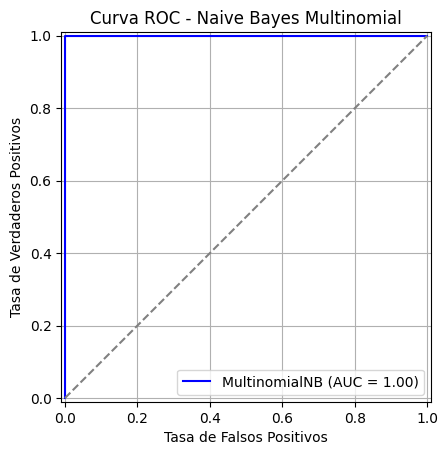

Matriz de confusión - Multinomial NB:
[[134   0]
 [  0 104]]


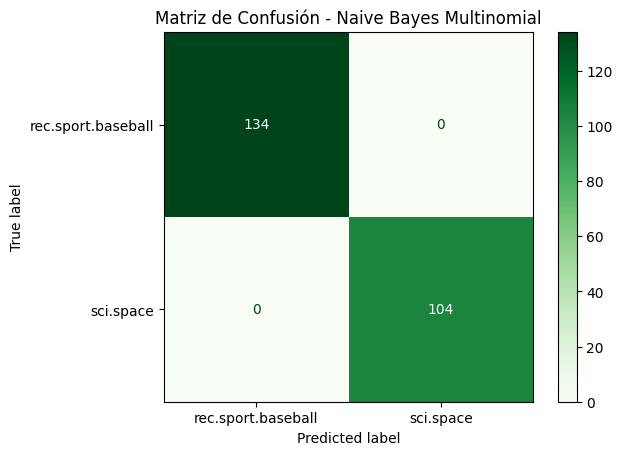

El Accuracy indica el porcentaje total de predicciones correctas entre casos benignos y malignos.
La Precision indica qué tan confiables son las predicciones de casos malignos realizadas por el modelo.
El Recall indica qué tan bien el modelo detecta los casos malignos reales.
El F1-Score resume Precision y Recall para la clase maligna.
El AUC-ROC indica qué tan bien el modelo separa los casos benignos de los malignos.


In [18]:


#Naive Bayes multinomial

categorias=[
    'sci.space',
    'rec.sport.baseball'
]

datos=fetch_20newsgroups(subset='train', categories=categorias)
target_names=datos.target_names
vectorizador = CountVectorizer()

Xm=vectorizador.fit_transform(datos.data)
ym=datos.target

X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size=0.2, random_state=24)

modeloM = MultinomialNB()

modeloM.fit (X_trainM, y_trainM)

y_predM=modeloM.predict(X_testM)

# Probabilidades necesarias para calcular AUC-ROC
y_probM = modeloM.predict_proba(X_testM)[:, 1]

print("Predicciones completadas con éxito.")
print("Accuracy Multinomial NB",
    accuracy_score(
        y_testM,
        y_predM
    )
)
#TODO: REALIZAR CONTRASTE CON OTRAS METRICAS DE EVALUACIÓN E INTERPRETAR RESULTADOS.
# Y VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN

print("Precision Multinomial NB:",
    precision_score(
        y_testM,
        y_predM,
        zero_division=0
    )
)

print("Recall Multinomial NB:",
    recall_score(
        y_testM,
        y_predM
    )
)

print("F1-Score Multinomial NB:",
    f1_score(
        y_testM,
        y_predM
    )
)

print("AUC-ROC Multinomial NB:",
    roc_auc_score(
        y_testM,
        y_probM
    )
)

print("\nReporte de clasificación - Multinomial NB:")
print(
    classification_report(
        y_testM,
        y_predM,
        target_names=target_names,
        zero_division=0
    )
)
#Curva ROC-AUC
RocCurveDisplay.from_predictions(
    y_testM,
    y_probM,
    name="MultinomialNB",
    color="blue"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Naive Bayes Multinomial")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.grid()
plt.show()

# MATRIZ DE CONFUSIÓN


matriz_multinomial = confusion_matrix(
    y_testM,
    y_predM
)

print("Matriz de confusión - Multinomial NB:")
print(matriz_multinomial)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_multinomial,
    display_labels=target_names
)

disp.plot(cmap="Greens")
plt.title("Matriz de Confusión - Naive Bayes Multinomial")
plt.show()




# Interpretación Multinomial NB:
El modelo MultinomialNB fue aplicado a un problema de clasificación de textos.
Los textos fueron transformados en valores numéricos mediante CountVectorizer, que representa la frecuencia de palabras.Este tipo de representación es adecuada para MultinomialNB, porque el modelo trabaja bien con datos de conteo.

El Accuracy indica el porcentaje total de documentos clasificados correctamente entre las categorías seleccionadas.

La Precision indica qué tan confiables son las predicciones realizadas para la clase positiva del modelo.

El Recall indica cuántos documentos reales de la clase positiva fueron identificados correctamente.

El F1-Score resume el equilibrio entre Precision y Recall en la clasificación de textos.
El AUC-ROC indica qué tan bien el modelo diferencia entre documentos de béisbol y documentos sobre el espacio.

La matriz de confusión permite observar cuántos textos fueron clasificados correctamente y cuántos fueron confundidos entre ambas categorías.

Si las métricas son altas, significa que las palabras presentes en los textos permiten distinguir adecuadamente entre las dos categorías.

Accuracy Bernoulli NB 0.9473684210526315
Precision Bernoulli NB: 0.9069767441860465
Recall Bernoulli NB: 0.9512195121951219
F1-Score Bernoulli NB: 0.9285714285714286
AUC-ROC Bernoulli NB: 0.9722686267958569

Reporte de clasificación - Bernoulli NB:
              precision    recall  f1-score   support

      benign       0.97      0.95      0.96        73
   malignant       0.91      0.95      0.93        41

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



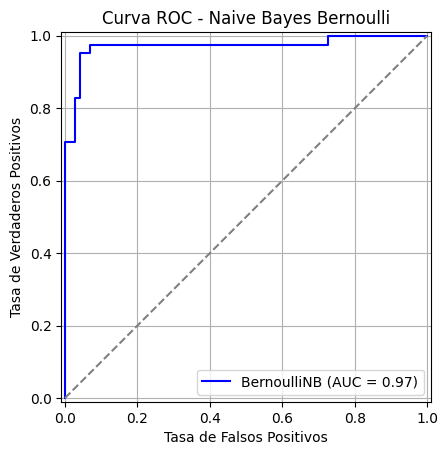

Matriz de confusión - Bernoulli NB:
[[69  4]
 [ 2 39]]


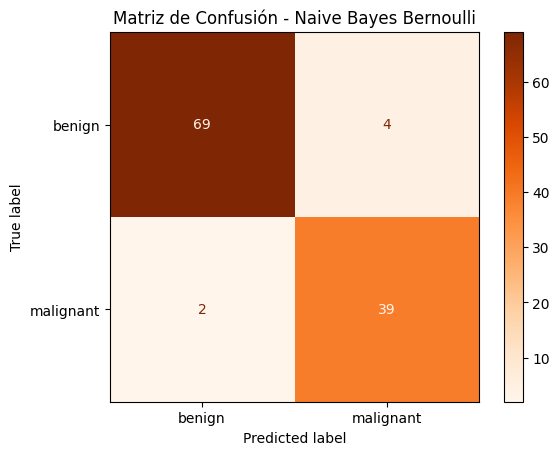


Interpretación Bernoulli NB:
BernoulliNB fue aplicado después de transformar las variables continuas en variables binarias.
La clase positiva es maligno, por lo que Precision, Recall y F1-Score evalúan principalmente la detección de casos malignos.
El Accuracy muestra el porcentaje general de aciertos del modelo.
La Precision indica qué tan confiables son las predicciones de malignidad.
El Recall indica qué proporción de casos malignos reales fueron detectados.
El F1-Score resume el equilibrio entre Precision y Recall.
El AUC-ROC mide la capacidad del modelo para diferenciar entre casos benignos y malignos.
La matriz de confusión permite identificar falsos positivos y falsos negativos.


In [ ]:

#Transformacion de variables continuas a discretas

umbral = np.median(X_train, axis=0)

X_train_bin = (X_train > umbral).astype(int)
X_test_bin = (X_test > umbral).astype(int)

modeloB=BernoulliNB()

modeloB.fit(X_train_bin,y_train)

yb_pred = modeloB.predict(X_test_bin)

# Probabilidades necesarias para calcular AUC-ROC
yb_prob = modeloB.predict_proba(X_test_bin)[:, 1]

print("Accuracy Bernoulli NB",
    accuracy_score(
        y_test,
        yb_pred
    )
)

print("Precision Bernoulli NB:",
    precision_score(
        y_test,
        yb_pred,
        zero_division=0
    )
)

print("Recall Bernoulli NB:",
    recall_score(
        y_test,
        yb_pred
    )
)

print("F1-Score Bernoulli NB:",
    f1_score(
        y_test,
        yb_pred
    )
)

print("AUC-ROC Bernoulli NB:",
    roc_auc_score(
        y_test,
        yb_prob
    )
)

print("\nReporte de clasificación - Bernoulli NB:")
print(
    classification_report(
        y_test,
        yb_pred,
        target_names=nombres_clases,
        zero_division=0
    )
)

#Curva ROC-AUC
RocCurveDisplay.from_predictions(
    y_test,
    yb_prob,
    name="BernoulliNB",
    color="blue"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Naive Bayes Bernoulli")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.grid()
plt.show()

# MATRIZ DE CONFUSIÓN


matriz_bernoulli = confusion_matrix(
    y_test,
    yb_pred
)

print("Matriz de confusión - Bernoulli NB:")
print(matriz_bernoulli)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_bernoulli,
    display_labels=nombres_clases
)

disp.plot(cmap="Oranges")
plt.title("Matriz de Confusión - Naive Bayes Bernoulli")
plt.show()



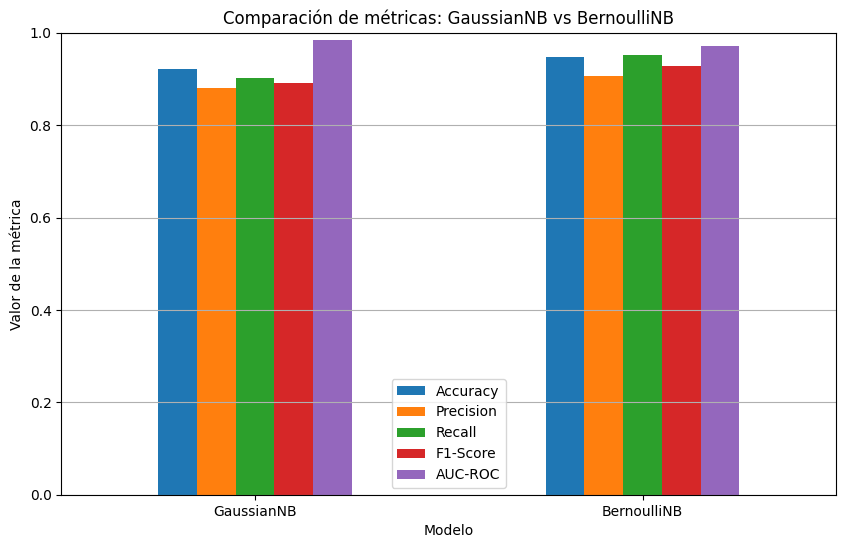

In [ ]:
comparacion_gauss_bernoulli = pd.DataFrame({
    "Modelo": [
        "GaussianNB",
        "BernoulliNB"
    ],
    "Tipo de datos que usa mejor": [
        "Variables continuas",
        "Variables binarias"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, yb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, yb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, yb_pred, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, yb_pred, zero_division=0)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, yb_prob)
    ]
})

comparacion_gauss_bernoulli

comparacion_gauss_bernoulli.set_index("Modelo")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de métricas: GaussianNB vs BernoulliNB")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


#Interpretación Bernoulli NB:

BernoulliNB fue aplicado después de transformar las variables continuas en variables binarias, mediante la mediana de cada variable.

La clase positiva es maligno, por lo que Precision, Recall y F1-Score evalúan principalmente la detección de casos malignos.

El Accuracy muestra el porcentaje general de aciertos del modelo.

La Precision indica qué tan confiables son las predicciones de malignidad.

El Recall indica qué proporción de casos malignos reales fueron detectados.

El F1-Score resume el equilibrio entre Precision y Recall.

El AUC-ROC mide la capacidad del modelo para diferenciar entre casos benignos y malignos.

La matriz de confusión permite identificar falsos positivos y falsos negativos.

No se compara el modelo Multinomial porque usa datos de texto convertidos en palabras para la realización de un conteo.

